In [0]:
%pip install snowflake-connector-python pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 23.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.3
    Not uninstalling requests at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-72623de0-4d5d-41a4-9ea1-52aeea4b29b1
    Can't uninstall 'requests'. No files were found to uninstall.
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Not uninstalling cffi at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-72623de0-4d5d-41a4-9ea1-52aeea4b29b1
    Can't uninstall 'cffi'. No files were found to uninstall.
  Attempting uninstall: cryptography
    Found existing installation: cryptography 44.0.1
    Not uninstalling cryptography at /databricks/python3/lib/python3.12/site-packages, outside environment /lo

In [0]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All packages imported successfully")

✅ All packages imported successfully


In [0]:
conn = snowflake.connector.connect(
    user     = "abhargav0021",
    password = "8pbsRD2ehLx2zZC",
    account  = "HHTWMXA-GQ18276",
    warehouse= "COMPUTE_WH",
    database = "PHARMA_DB",
    schema   = "GOLD"
)
print("✅ Connected!")

✅ Connected!


In [0]:
cursor = conn.cursor()

# Load all 3 tables into Pandas DataFrames
cursor.execute("SELECT * FROM MONTHLY_DRUG_SALES")
df_monthly = pd.DataFrame(cursor.fetchall(),
    columns=[desc[0] for desc in cursor.description])

cursor.execute("SELECT * FROM TOP_DRUGS")
df_top_drugs = pd.DataFrame(cursor.fetchall(),
    columns=[desc[0] for desc in cursor.description])

cursor.execute("SELECT * FROM WEEKDAY_SALES")
df_weekday = pd.DataFrame(cursor.fetchall(),
    columns=[desc[0] for desc in cursor.description])

print("✅ Connected to Snowflake successfully")
print(f"Monthly sales rows : {len(df_monthly)}")
print(f"Top drugs rows     : {len(df_top_drugs)}")
print(f"Weekday sales rows : {len(df_weekday)}")

✅ Connected to Snowflake successfully
Monthly sales rows : 560
Top drugs rows     : 8
Weekday sales rows : 56


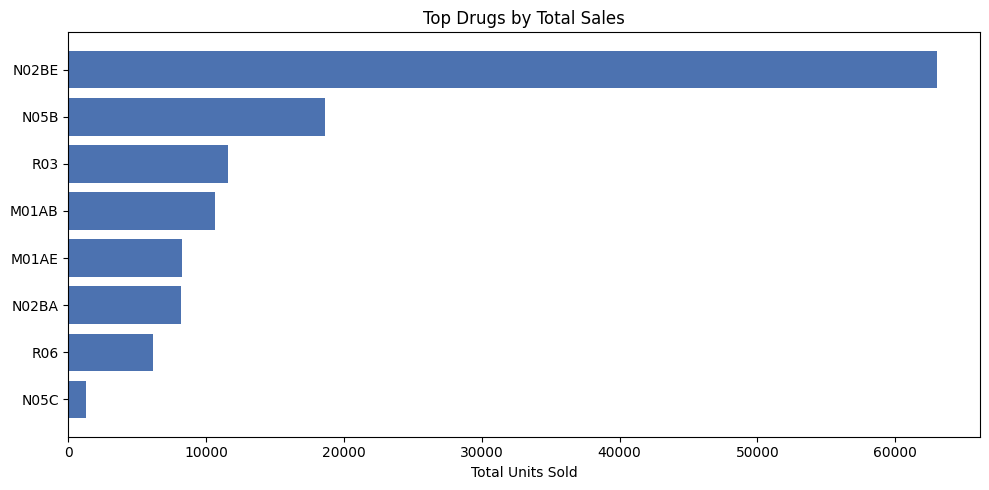

In [0]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
df_top_drugs_sorted = df_top_drugs.sort_values("TOTAL_UNITS_SOLD", ascending=True)

ax.barh(df_top_drugs_sorted["DRUG_NAME"],
        df_top_drugs_sorted["TOTAL_UNITS_SOLD"],
        color="#4C72B0")

ax.set_xlabel("Total Units Sold")
ax.set_title("Top Drugs by Total Sales")
plt.tight_layout()
plt.show()

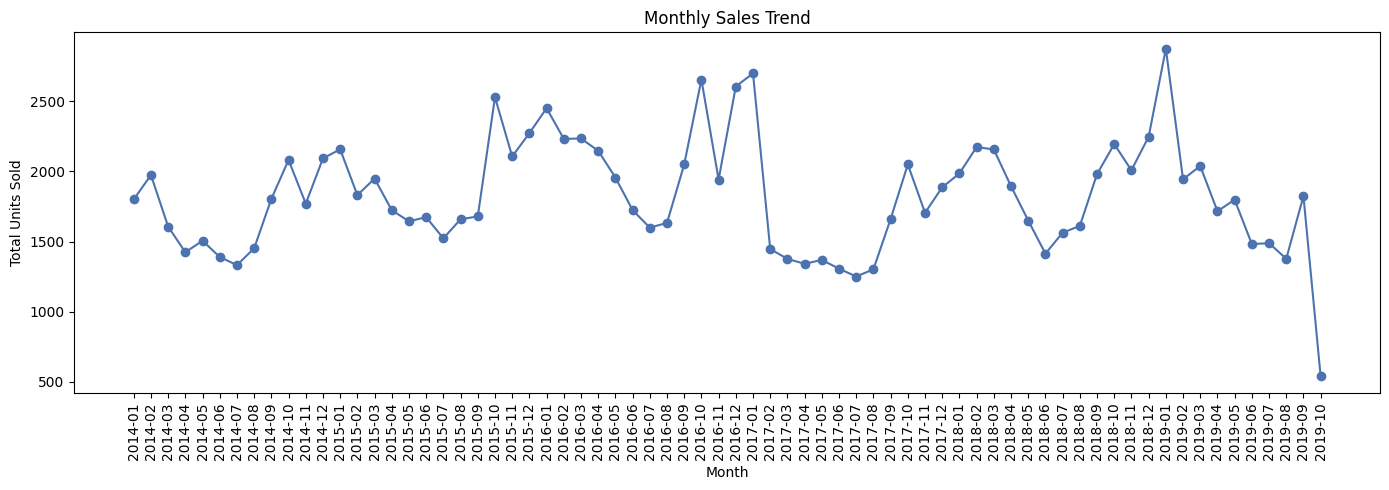

In [0]:
df_trend = df_monthly.groupby(["YEAR", "MONTH"])["TOTAL_UNITS_SOLD"] \
    .sum().reset_index()

df_trend["year_month"] = df_trend["YEAR"].astype(str) + "-" + \
    df_trend["MONTH"].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_trend["year_month"],
        df_trend["TOTAL_UNITS_SOLD"],
        marker="o", linewidth=1.5, color="#4C72B0")

ax.set_xlabel("Month")
ax.set_ylabel("Total Units Sold")
ax.set_title("Monthly Sales Trend")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

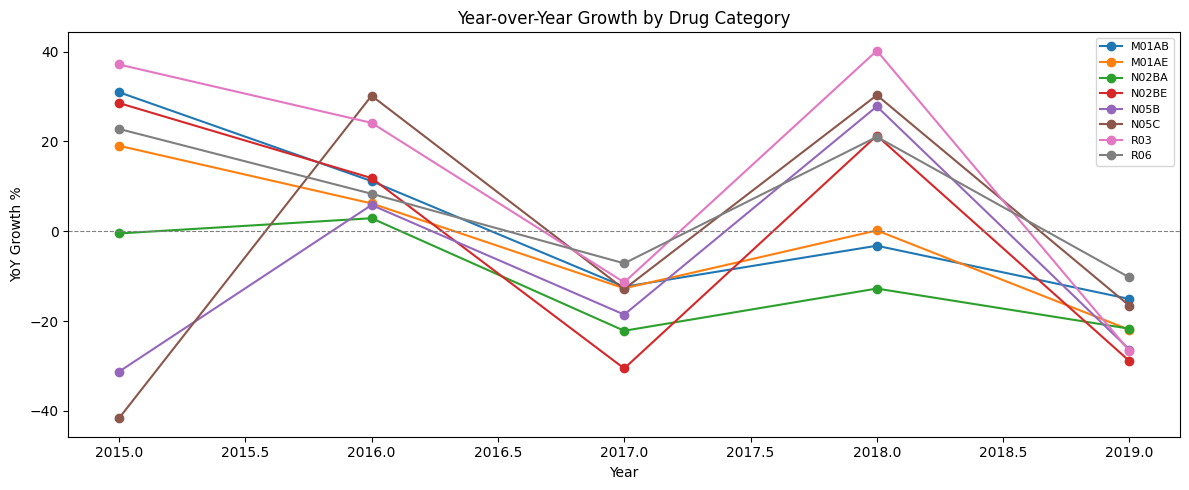

In [0]:
df_yoy = df_monthly.groupby(["YEAR", "DRUG_NAME"])["TOTAL_UNITS_SOLD"] \
    .sum().reset_index()

df_yoy = df_yoy.sort_values(["DRUG_NAME", "YEAR"])
df_yoy["PREV_YEAR"] = df_yoy.groupby("DRUG_NAME")["TOTAL_UNITS_SOLD"].shift(1)
df_yoy["YOY_GROWTH_PCT"] = ((df_yoy["TOTAL_UNITS_SOLD"] - df_yoy["PREV_YEAR"]) \
    / df_yoy["PREV_YEAR"] * 100).round(2)

df_yoy_clean = df_yoy.dropna(subset=["YOY_GROWTH_PCT"])

fig, ax = plt.subplots(figsize=(12, 5))
for drug in df_yoy_clean["DRUG_NAME"].unique():
    drug_data = df_yoy_clean[df_yoy_clean["DRUG_NAME"] == drug]
    ax.plot(drug_data["YEAR"], drug_data["YOY_GROWTH_PCT"],
            marker="o", label=drug)

ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("YoY Growth %")
ax.set_title("Year-over-Year Growth by Drug Category")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

/home/spark-72623de0-4d5d-41a4-9ea1-52/.ipykernel/2010/command-7074321267962978-3559127171:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_wd, x="WEEKDAY_NAME",


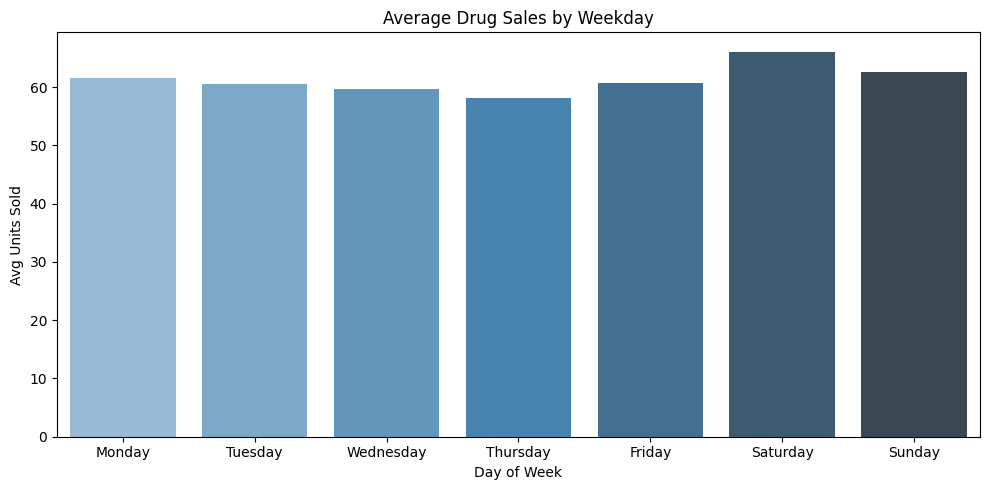

In [0]:
import seaborn as sns

df_wd = df_weekday.groupby("WEEKDAY_NAME")["AVG_UNITS_SOLD"] \
    .sum().reset_index()

# Order days correctly
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]
df_wd["WEEKDAY_NAME"] = pd.Categorical(df_wd["WEEKDAY_NAME"],
    categories=day_order, ordered=True)
df_wd = df_wd.sort_values("WEEKDAY_NAME")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_wd, x="WEEKDAY_NAME",
            y="AVG_UNITS_SOLD", palette="Blues_d", ax=ax)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Avg Units Sold")
ax.set_title("Average Drug Sales by Weekday")
plt.tight_layout()
plt.show()